In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("apps.csv")

In [5]:
df.shape

(9659, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [7]:
df.describe()

,Unnamed: 0,Rating,Reviews,Size
count,9659.000000,8196.000000,9.659000e+03,8432.000000
mean,5666.172896,4.173243,2.165926e+05,20.395327
std,3102.362863,0.536625,1.831320e+06,21.827509
min,0.000000,1.000000,0.000000e+00,0.000000
25%,3111.500000,4.000000,2.500000e+01,4.600000
50%,5814.000000,4.300000,9.670000e+02,12.000000
75%,8327.500000,4.500000,2.940100e+04,28.000000
max,10840.000000,5.000000,7.815831e+07,100.000000


In [8]:
df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Fill Missing Rating

In [10]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

Fill Missing Size

In [11]:
df["Size"] = df["Size"].fillna("Unknown")

Fill Missing Current Version

In [12]:
df["Current Ver"] = df["Current Ver"].fillna("Unknown")

Fill Missing Android Version

In [13]:
df["Android Ver"] = df["Android Ver"].fillna("Unknown")

In [14]:
df.isnull().sum()

Unnamed: 0        0
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Clean Installs Column

In [15]:
df["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [16]:
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [17]:
df.describe()

,Unnamed: 0,Rating,Reviews,Installs
count,9659.000000,9659.000000,9.659000e+03,9.659000e+03
mean,5666.172896,4.192442,2.165926e+05,7.777507e+06
std,3102.362863,0.496397,1.831320e+06,5.375828e+07
min,0.000000,1.000000,0.000000e+00,0.000000e+00
25%,3111.500000,4.000000,2.500000e+01,1.000000e+03
50%,5814.000000,4.300000,9.670000e+02,1.000000e+05
75%,8327.500000,4.500000,2.940100e+04,1.000000e+06
max,10840.000000,5.000000,7.815831e+07,1.000000e+09


In [18]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [19]:
df.dtypes

Unnamed: 0          int64
App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [20]:
df["Price"].unique()[:10]

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99'], dtype=object)

In [21]:
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"])

In [22]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [23]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          9659 non-null   float64       
 3   Reviews         9659 non-null   int64         
 4   Size            9659 non-null   object        
 5   Installs        9659 non-null   int64         
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9659 non-null   object        
 12  Android Ver     9659 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(8)
memory usage: 981.1+ KB


***Top 10 Categories***

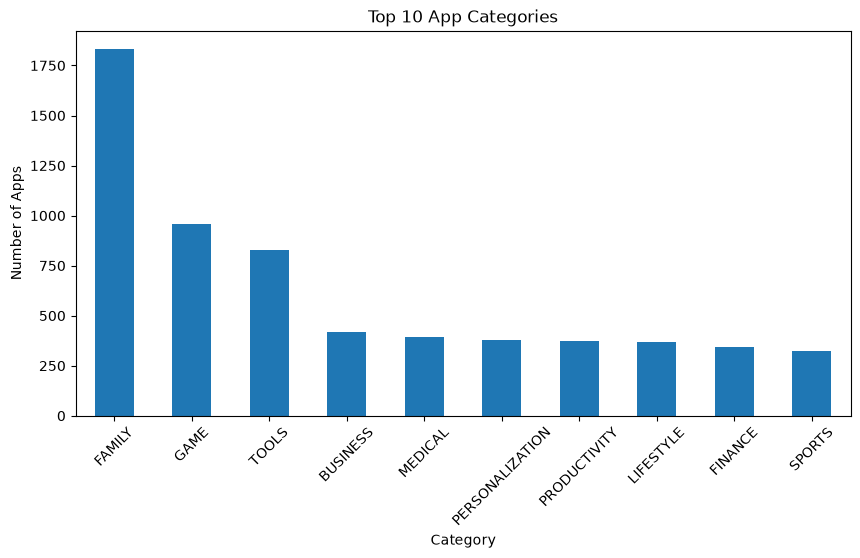

In [25]:
import matplotlib.pyplot as plt

df["Category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

***Free VS Paid Apps***

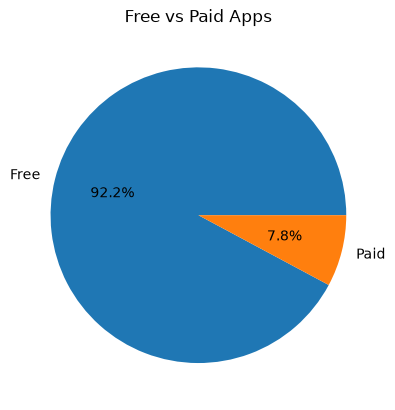

In [26]:
df["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Free vs Paid Apps")
plt.ylabel("")
plt.show()

***Rating Distribution***

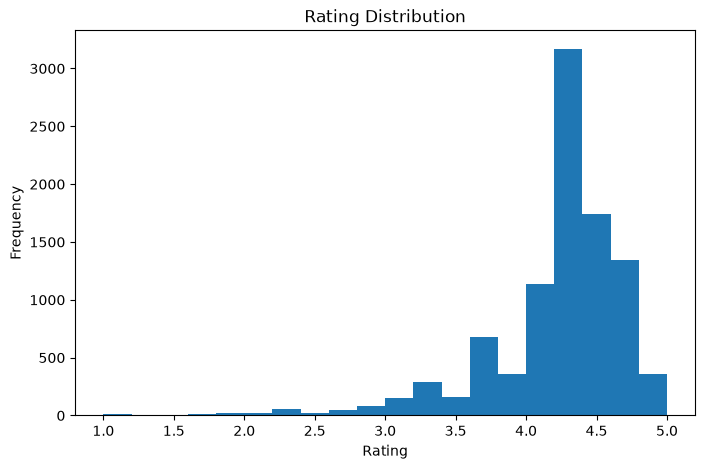

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Rating"], bins=20)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

***Top 10 Categories By Average Rating***

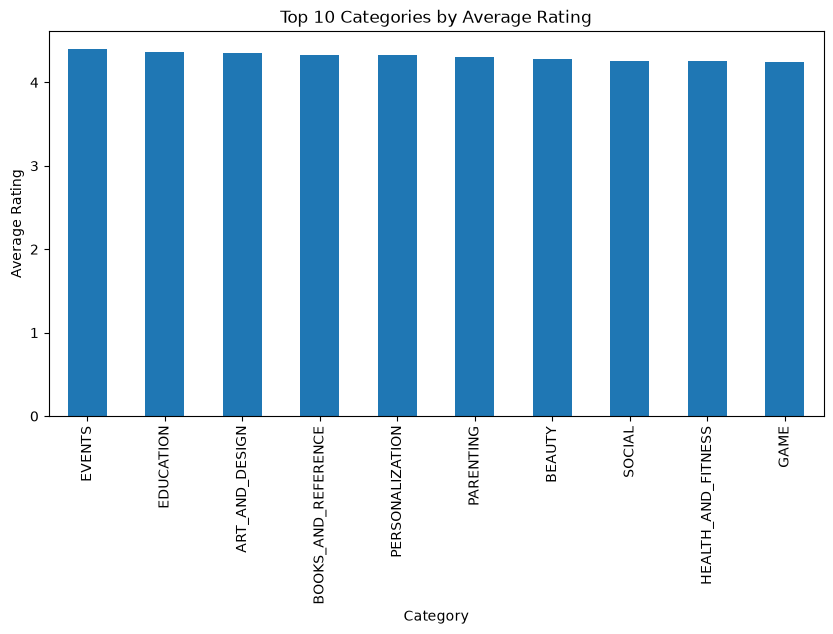

In [28]:
category_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False).head(10)

category_rating.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.show()

***Top 10 Categories by Total Installs***

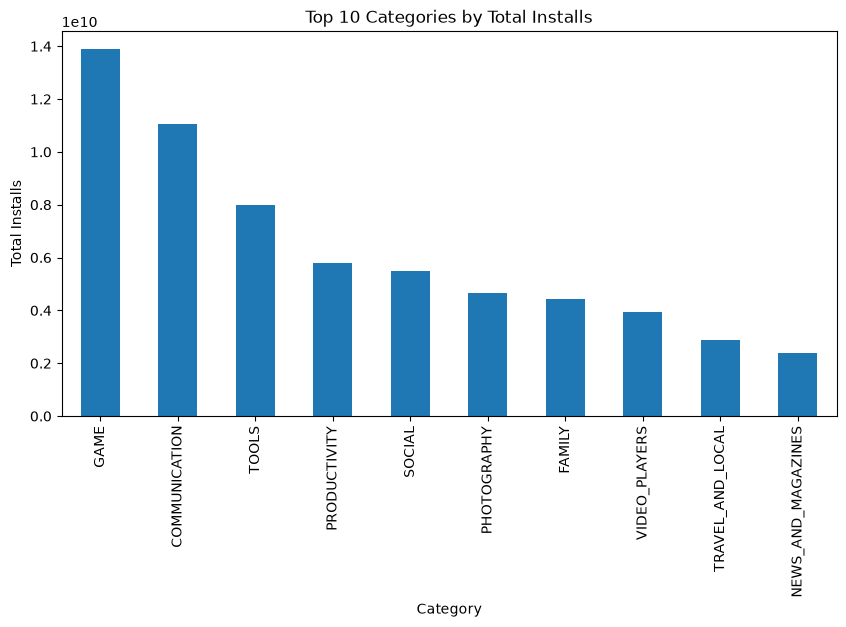

In [29]:
installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(10)

installs.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")

plt.show()

***Paid App Price Distribution***


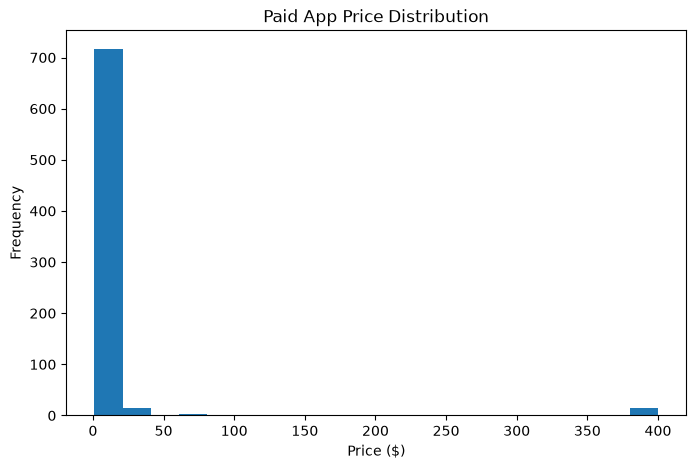

In [30]:
paid_apps = df[df["Price"] > 0]

plt.figure(figsize=(8,5))
plt.hist(paid_apps["Price"], bins=20)

plt.title("Paid App Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.show()

***Content Rating Distribution***

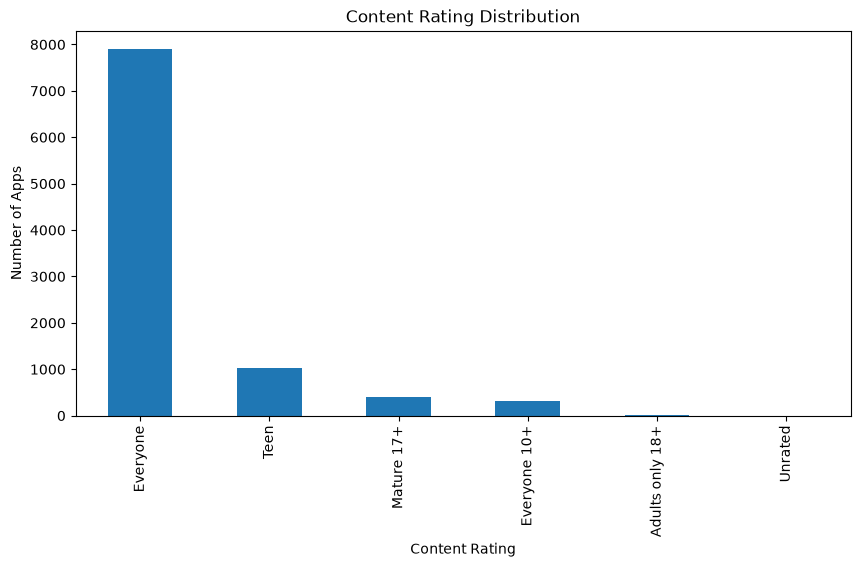

In [31]:
df["Content Rating"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Content Rating Distribution")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")

plt.show()

***Sentiment Distribution***

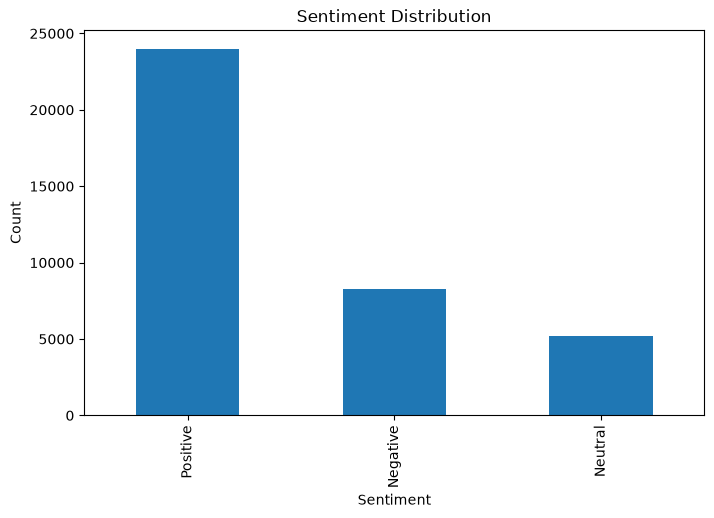

In [32]:
reviews = pd.read_csv("user_reviews.csv")

reviews["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

#Most reviews are positive, indicating overall user satisfaction with apps on the Google Play Store

***Average Sentiment by App***

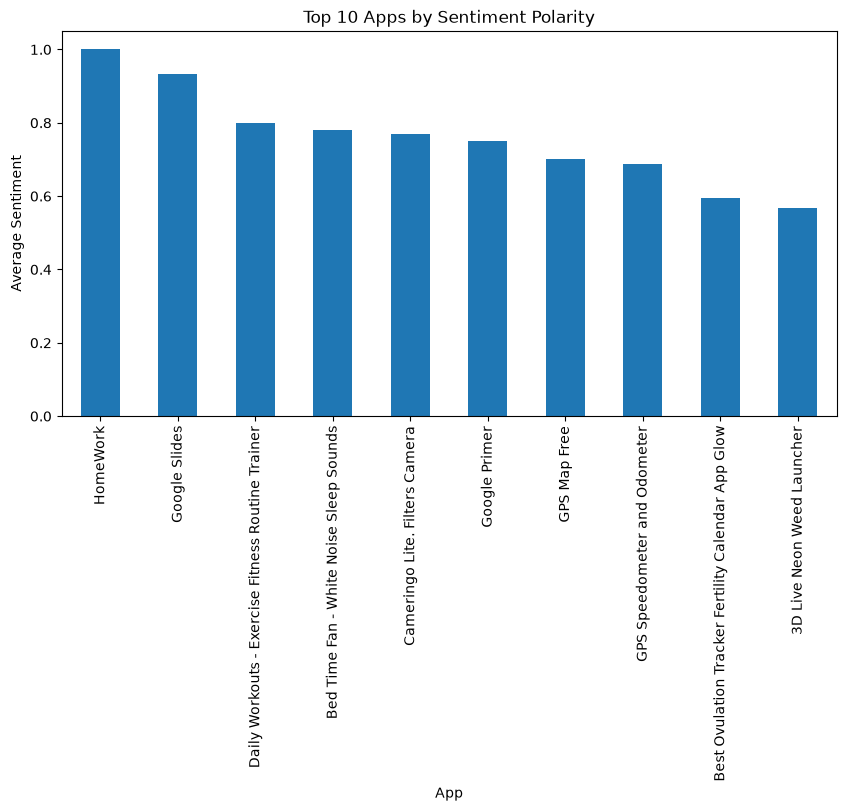

In [33]:
top_sentiment = (
    reviews.groupby("App")["Sentiment_Polarity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_sentiment.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Apps by Sentiment Polarity")
plt.xlabel("App")
plt.ylabel("Average Sentiment")
plt.show()

***Sentiment Breakdown***

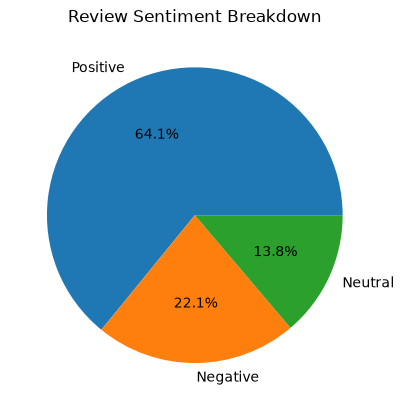

In [34]:
reviews["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Review Sentiment Breakdown")
plt.ylabel("")
plt.show()